<a href="https://colab.research.google.com/github/VENNELA2132/NN-practise/blob/main/Neural_Networks_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

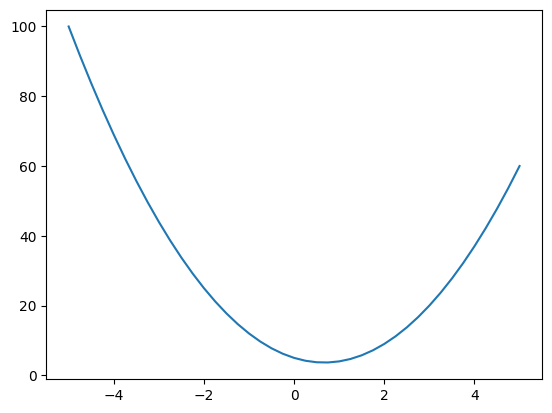

In [56]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


def f(x):
  return 3*x**2 - 4*x + 5


xs = np.arange(-5,5.25,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [91]:
from IPython.utils.openpy import read_py_url
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._prev = set(_children)
    self._backward = lambda: None
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    # print(self.label, self.data, self.grad, ",", other.label, other.data, other.grad, "out",out.data, out.label, out.grad)
    out._backward = _backward
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad

    out._backward = _backward
    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "Only supporting int/float powers for now"
    out = Value(self.data ** other, (self,), f'**{other}')

    def _backward():
      self.grad += (other) * (self.data**(other-1)) * out.grad

    out._backward = _backward
    return out
  def __rmul__(self, other):
    return self * other;
  def __radd__(self, other): # other + self
    return self + other

  def __truediv__(self, other):
    return self * (other**(-1));

  def __neg__(self):
    return self * -1;

  def __sub__(self, other):
    return self + (-other)

  def tanh(self):
    n = self.data
    t = (math.exp(2*n)-1) / (math.exp(2*n) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad

    out._backward = _backward
    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self,), 'exp')

    def _backward():
      self.grad += out.data * out.grad

    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    # print("topo\n",topo)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [92]:
a = Value(2.0, label='a')
b = Value(4.0, label='b')

1+a

Value(data=3.0)

In [93]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

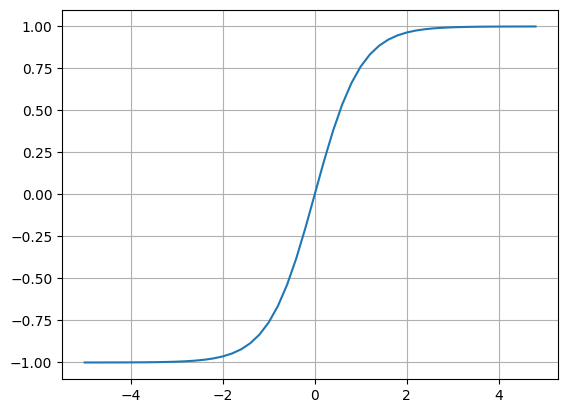

In [94]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [95]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

# #w1.grad = w1x1.grad * x1
# w1.grad = 0.5 * x1.data
# x1.grad = 0.5 * w1.data
# x2.grad = 0.5 * w2.data
# w2.grad = 0.5 * x2.data
# x2w2.grad = 0.5
# x1w1.grad = 0.5
# b.grad = 0.5
# x1w1x2w2.grad = 0.5
# # n.grad = 1 - (o.data * o.data)
# n.grad = 0.5
# o.grad = 1

# o.grad = 1
# o._backward()
# n._backward()
# x1w1x2w2._backward()
# x2w2._backward()
# x1w1._backward()



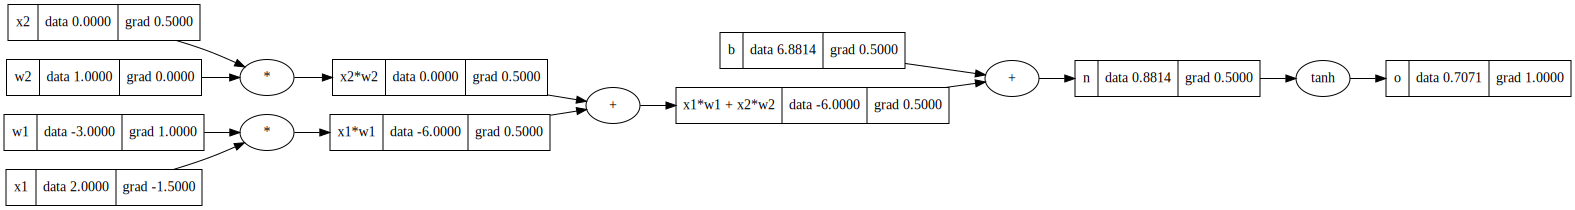

In [96]:
# o.grad = 1.0

# topo = []
# visited = set()
# def build_topo(v):
#   if v not in visited:
#     visited.add(v)
#     for child in v._prev:
#       build_topo(child)
#     topo.append(v)
# build_topo(o)

# for node in reversed(topo):
#   node._backward()

# topo

o.backward()

draw_dot(o)

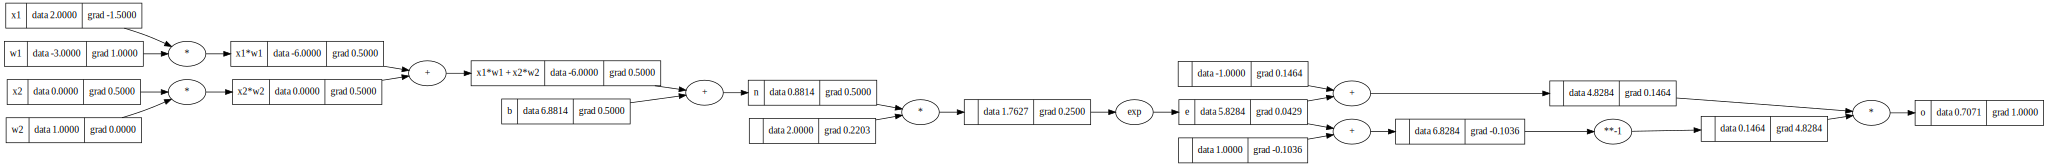

In [97]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
#############
e = (2*n).exp(); e.label='e'
o = (e - 1) / (e + 1)
#############
o.label = 'o'

o.backward()
draw_dot(o)

In [98]:
import torch

In [99]:
x1 = torch.Tensor([2.0]).double()               ;x1.requires_grad=True
x2 = torch.Tensor([0.0]).double()               ;x2.requires_grad=True
w1 = torch.Tensor([-3.0]).double()              ;w1.requires_grad=True
w2 = torch.Tensor([1.0]).double()               ;w2.requires_grad=True
b = torch.Tensor([6.8813735870195432]).double() ;b.requires_grad=True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("-----------")
print("x1.grad ", x1.grad.item())
print("x2.grad ", x2.grad.item())
print("w1.grad ", w1.grad.item())
print("w2.grad ", w2.grad.item())

0.7071066904050358
-----------
x1.grad  -1.5000003851533106
x2.grad  0.5000001283844369
w1.grad  1.0000002567688737
w2.grad  0.0


In [100]:
x1.grad

tensor([-1.5000], dtype=torch.float64)

In [193]:
class Neuron:
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  def parameters(self):
    return self.w + [self.b]

class Layer:
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs)==1 else outs

  def parameters(self):
    params = []
    for neuron in self.neurons:
      ps = neuron.parameters()
      params.extend(ps)
    return params

class MLP:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    params = []
    for layer in self.layers:
      ps = layer.parameters()
      params.extend(ps)
    return params


In [238]:
x = [2.0, 3.0, 5.0]
n = MLP(3,[4, 4, 1])
n(x)

Value(data=-0.9241658987333217)

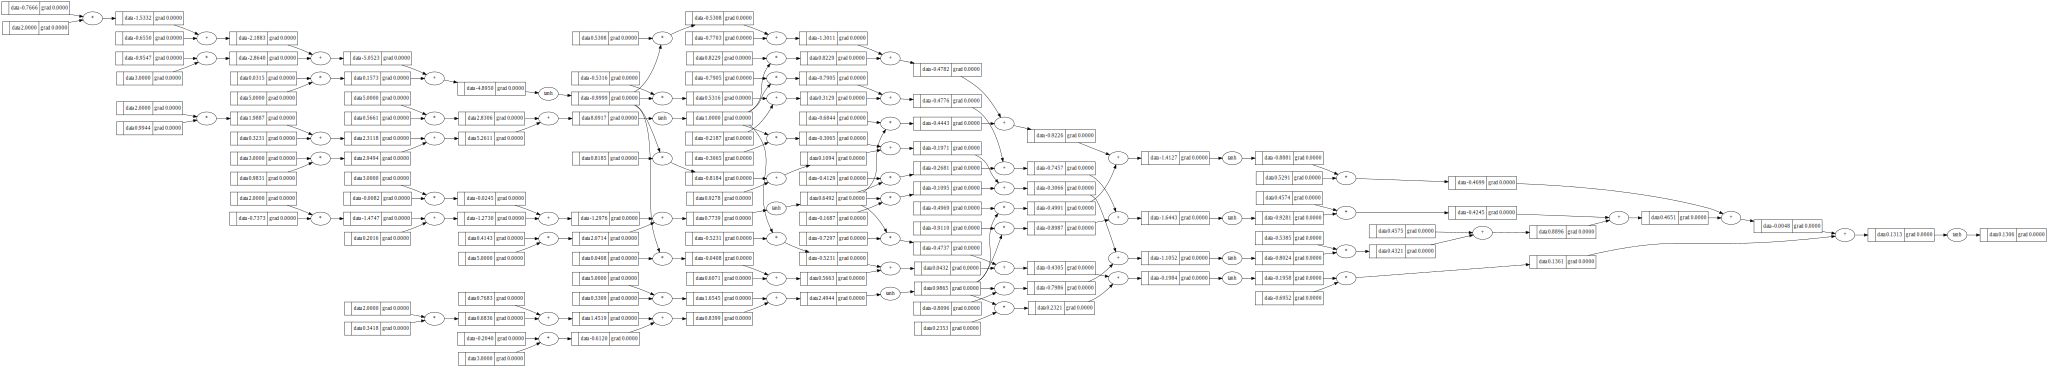

In [195]:
draw_dot(n(x))

In [239]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [266]:
for k in range(10):
  #forward pass
  ypred = [n(x) for x in xs]
  loss = sum((y1 - y2)**2 for y1,y2 in zip(ypred,ys))

  #backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  #update
  for p in n.parameters():
    p.data += (-0.01) * p.grad

  print(k, loss.data)

0 0.010279572932859256
1 0.010232288275896227
2 0.010185421742005245
3 0.010138967899967212
4 0.010092921411264727
5 0.010047277028127058
6 0.010002029591624039
7 0.009957174029807411
8 0.009912705355898574
9 0.009868618666521141


In [267]:
ypred

[Value(data=0.9494060744559285),
 Value(data=-0.9762918451364428),
 Value(data=-0.9377426214108314),
 Value(data=0.946420007757255)]

In [262]:
ypred = [n(x) for x in xs]
ypred

[Value(data=0.9441859087881062),
 Value(data=-0.9743362368250847),
 Value(data=-0.9314810143951998),
 Value(data=0.9412189084869134)]

In [198]:
loss = sum((y1 - y2)**2 for y1,y2 in zip(ypred,ys))
loss

Value(data=3.9913060658962936)

In [235]:
ypred = [n(x) for x in xs]
loss = sum((y1 - y2)**2 for y1,y2 in zip(ypred,ys))
loss

Value(data=0.055840802755221075)

In [236]:
loss.backward()

In [234]:
for p in n.parameters():
  p.data += (-0.01)*(p.grad)

In [237]:
ypred

[Value(data=0.9331664655673948),
 Value(data=-0.8459032388464668),
 Value(data=-0.8871968327218173),
 Value(data=0.8779192272121932)]

In [204]:
len(n.parameters())

41

In [213]:
n.layers[0].neurons[0].w[2].grad

-0.11425931326945694

In [223]:
n.layers[0].neurons[0].w[2].data

0.03697998013893138

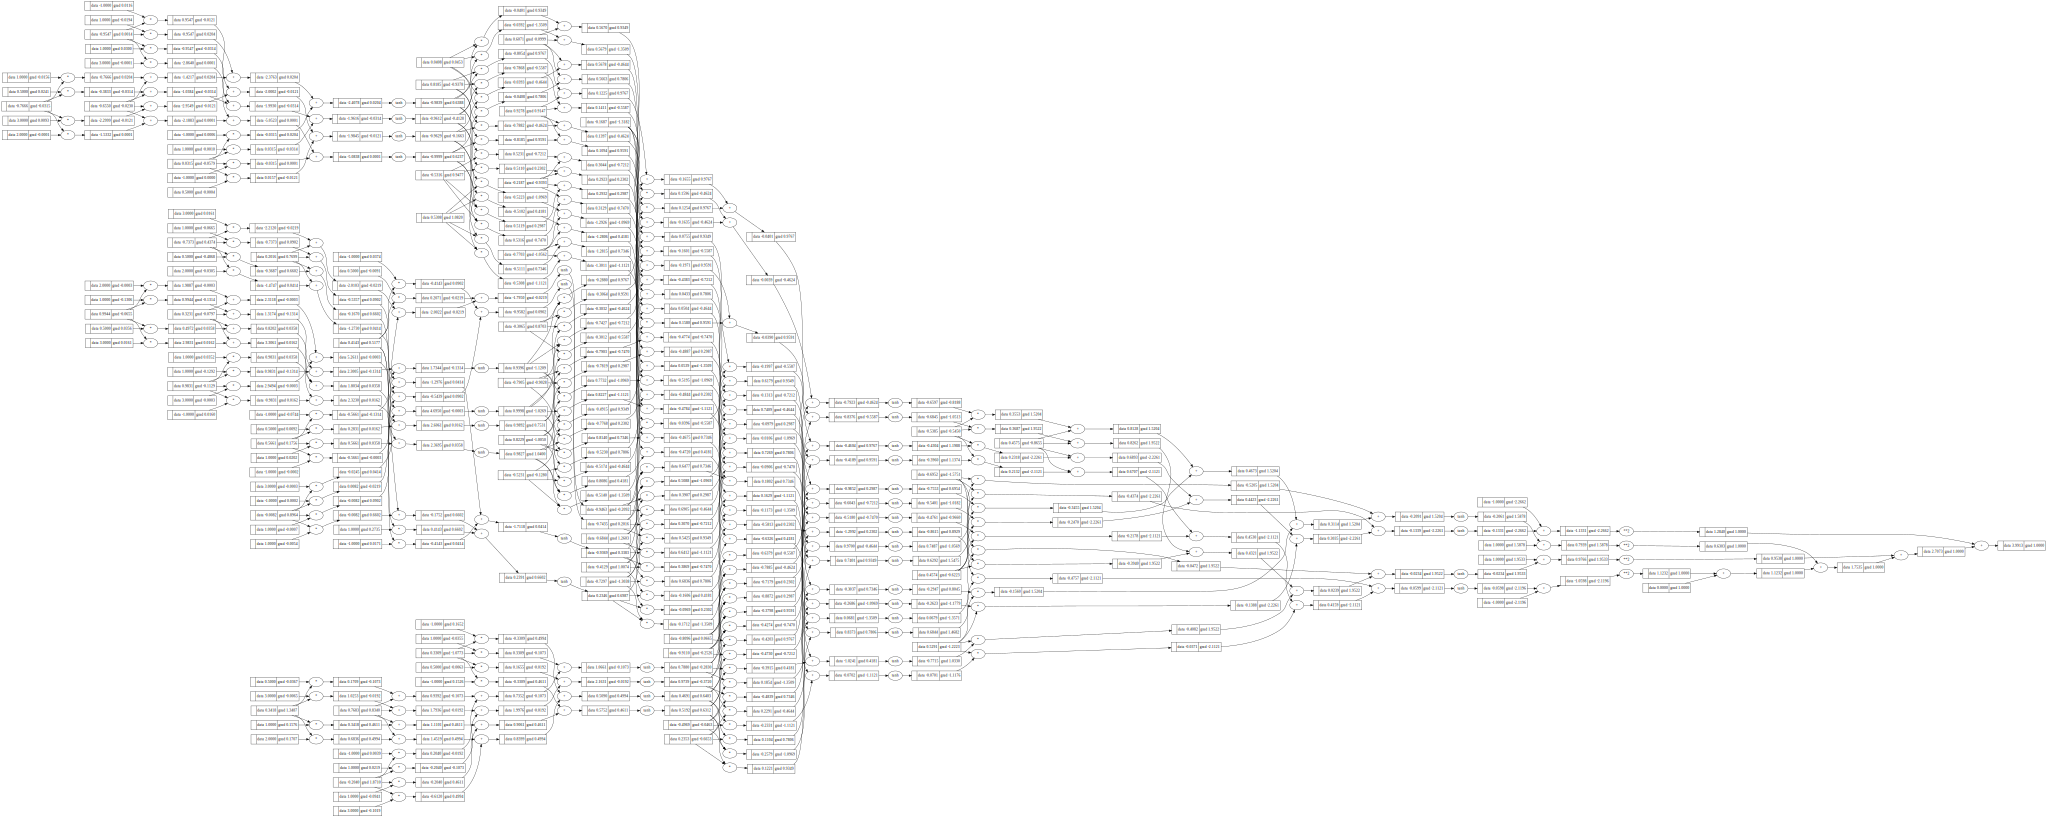

In [201]:
draw_dot(loss)

In [202]:
n.parameters()

[Value(data=-0.7666242256269509),
 Value(data=-0.9546707522545621),
 Value(data=0.031457561786016885),
 Value(data=-0.6550393800842076),
 Value(data=0.9943545024013798),
 Value(data=0.9831200493745487),
 Value(data=0.5661196011226461),
 Value(data=0.32306189936544216),
 Value(data=-0.7373260746220567),
 Value(data=-0.00818171393196132),
 Value(data=0.4142883784728435),
 Value(data=0.20164114409366074),
 Value(data=0.3417805412925239),
 Value(data=-0.20399439490969318),
 Value(data=0.33090929718774875),
 Value(data=0.7683070695371879),
 Value(data=0.8185331263351616),
 Value(data=-0.3064883490407564),
 Value(data=-0.16866764055156103),
 Value(data=-0.8095788846360046),
 Value(data=0.9278447672152761),
 Value(data=-0.5316493921929026),
 Value(data=-0.7904624518433587),
 Value(data=-0.41292431105082095),
 Value(data=-0.9110119225575879),
 Value(data=-0.2187190354453199),
 Value(data=0.5308166376170587),
 Value(data=0.8228727350552749),
 Value(data=-0.68444025030113),
 Value(data=-0.496857